<a href="https://colab.research.google.com/github/sokrypton/ml4me/blob/main/AlphaFold_approx_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install py2Dmol

import os
import numpy as np
from sklearn.manifold import MDS
from matplotlib import pyplot as plt
import py2Dmol

def get_ca(x):
  xyz = []
  with open(x,"r") as file:
    for line in file:
      line = line.rstrip()
      if line[:4] == "ATOM":
        atom = line[12:12+4].strip()
        if atom == "CA":
          resi = line[17:17+3]
          resn = int(line[22:22+5])-1
          x = float(line[30:30+8])
          y = float(line[38:38+8])
          z = float(line[46:46+8])
          xyz.append([x,y,z])
  return np.array(xyz)

def xyz_to_dm(X):
  return np.sqrt(np.sum(np.square(X[None,:]-X[:,None]),axis=-1))

# aka outer-product-mean
def get_coevolution(X):
  Y = np.eye(21)[X]
  N,L,A = Y.shape
  Y_flat = Y.reshape(N,-1)
  # covariance
  c = np.cov(Y_flat.T)

  # inverse covariance
  shrink = 4.5/np.sqrt(N) * np.eye(c.shape[0])
  ic = np.linalg.inv(c + shrink)

  # partial correlation coefficient
  ic_diag = np.diag(ic)
  pcc = ic / np.sqrt(ic_diag[:,None] * ic_diag[None,:])

  # l2norm
  raw = np.sqrt(np.square(pcc.reshape(L,A,L,A)[:,:20,:,:20]).sum((1,3)))
  np.fill_diagonal(raw,0)

  # do apc
  ap = raw.sum(0,keepdims=True) * raw.sum(1,keepdims=True) / raw.sum()
  apc = (raw - ap)
  np.fill_diagonal(apc,0)
  return apc

# aka triangle attention/updates
def floyd_warshall(d):
  for m in range(d.shape[0]):
    o = d[m]
    oo = o[None,:]+o[:,None]
    d = np.minimum(d, oo)
  return d

# aka structure module
def classic_mds(M):
  L = M.shape[0]
  d = np.square(M)
  c = np.eye(L) - np.ones((L,L))/L
  m = -0.5 * c @ d @ c
  s,u = np.linalg.eigh(m)
  X = u[:,-3:] * np.sqrt(s[-3:])
  return X

def metric_mds(x):
  return MDS(3,dissimilarity="precomputed").fit_transform(x)

def parse_a3m(filepath):
    """Parse a3m file and remove lowercase letters"""
    sequences = []
    headers = []

    with open(filepath, 'r') as f:
        header = None
        seq = ""

        for line in f:
            line = line.strip()
            if line.startswith('>'):
                if header:
                    sequences.append(''.join([c for c in seq if c.isupper() or c == '-']))
                    headers.append(header)
                header = line
                seq = ""
            else:
                seq += line

        if header:
            sequences.append(''.join([c for c in seq if c.isupper() or c == '-']))
            headers.append(header)

    return sequences, headers

def seq_to_num(sequences):
  amino_acids = 'ACDEFGHIKLMNPQRSTVWY-'
  aa_to_idx = {aa: i for i, aa in enumerate(amino_acids)}

  seq_len = len(sequences[0])
  n_seqs = len(sequences)
  return np.array([[aa_to_idx.get(s,20) for s in seq] for seq in sequences])

if not os.path.isfile("filter"):
  os.system("wget -qnc https://raw.githubusercontent.com/sokrypton/msa-tools/refs/heads/main/filter.cpp")
  os.system("g++ -O3 -march=native -std=c++17 -fopenmp filter.cpp -o filter")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 36.5 MB/s eta 0:00:00


In [2]:
uniprot_id = "P0A8I3"

# Download structure and MSA from AlphaFold EBI database
os.system(f"wget -qnc https://alphafold.ebi.ac.uk/files/AF-{uniprot_id}-F1-model_v6.pdb")
os.system(f"wget -qnc https://alphafold.ebi.ac.uk/files/msa/AF-{uniprot_id}-F1-msa_v6.a3m")

# Filter MSA to reduce redundancy (optional but recommended)
# Parameters: -id 90 (remove sequences >90% identity), -cov 75 (75% coverage), -qid 15 (15% query identity)
os.system(f"./filter AF-{uniprot_id}-F1-msa_v6.a3m AF-{uniprot_id}-F1-msa_v6.filt.a3m -id 90 -cov 75 -qid 15")

0

In [3]:
xyz = get_ca(f"AF-{uniprot_id}-F1-model_v6.pdb")

v = py2Dmol.view(controls=False, cutoffs={"protein_bond":10})
v.add(xyz)
v.show()


In [4]:
sequences, headers = parse_a3m(f"AF-{uniprot_id}-F1-msa_v6.filt.a3m")
msa = seq_to_num(sequences)

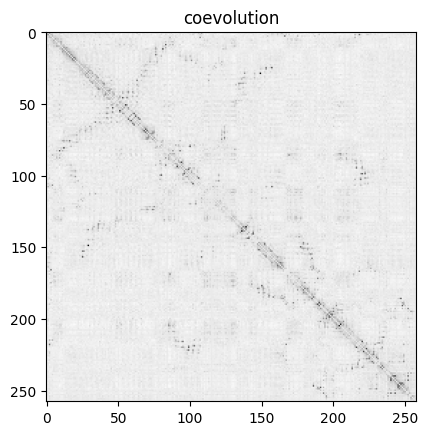

In [5]:
con = get_coevolution(msa)
plt.title("coevolution")
plt.imshow(con,cmap="grey_r")
plt.show()

4.214202209643616


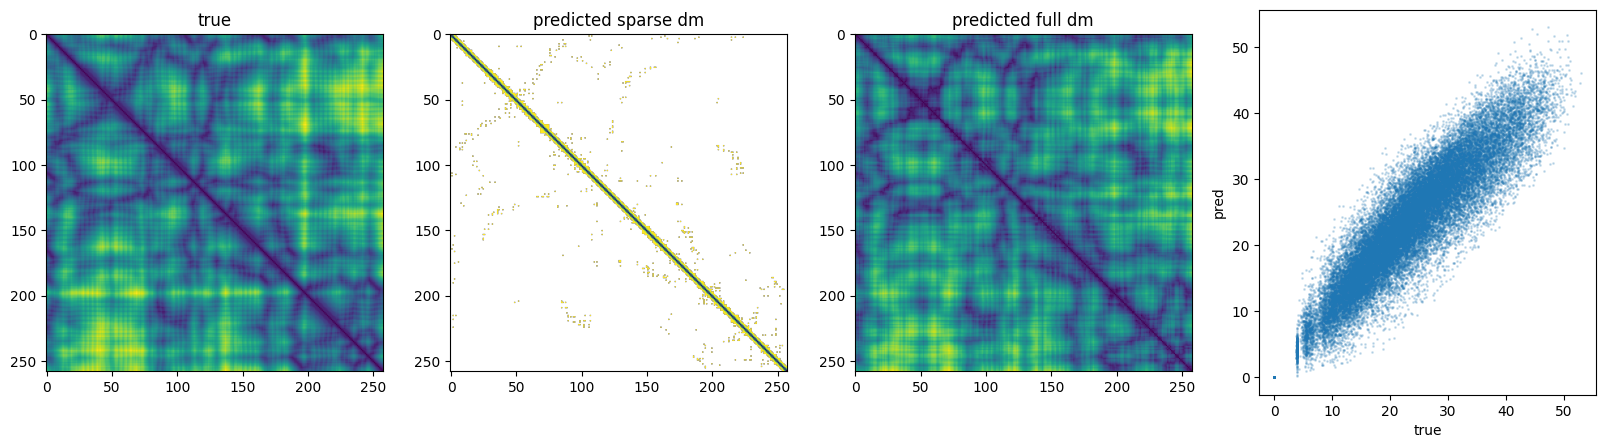

In [6]:
dm = xyz_to_dm(xyz)
idx = np.arange(dm.shape[0])
rel_pos = np.abs(idx[:,None] - idx[None,:])

sparse_dm = ((con > np.std(con) * 2.5) & (rel_pos > 3)).astype(float)

sparse_dm[sparse_dm == 0] = np.inf
sparse_dm[sparse_dm == 1] = 7.0
sparse_dm[rel_pos == 0] = 0.0
sparse_dm[rel_pos == 1] = 3.8 # consecutive Cα atoms are within 3.8Å
sparse_dm[rel_pos == 2] = 6.8
sparse_dm[rel_pos == 3] = 7.0

full_dm = floyd_warshall(sparse_dm)
xyz_recon = classic_mds(full_dm)
#xyz_recon = metric_mds(full_dm)
dm_fix = xyz_to_dm(xyz_recon)

print(np.sqrt(np.square(dm - dm_fix).mean()))

plt.figure(figsize=(20,5))
plt.subplot(1,4,1); plt.title("true"); plt.imshow(dm)
plt.subplot(1,4,2); plt.title("predicted sparse dm"); plt.imshow(sparse_dm)
plt.subplot(1,4,3); plt.title("predicted full dm"); plt.imshow(dm_fix)
plt.subplot(1,4,4); plt.scatter(dm, dm_fix, s=1, alpha=0.1); plt.xlabel("true"); plt.ylabel("pred")
plt.show()

In [7]:
v = py2Dmol.view(cutoffs={"protein_bond":10})
v.add(xyz)
v.add(xyz_recon, allow_reflection=True)
v.show()

In [8]:
!pip install py3Dmol

In [9]:
# =====================================================================
# Bonus Cell: Refine coevolution structure with ProteinEBM
# =====================================================================
# Takes xyz_recon from the coevolution MDS reconstruction and passes it
# through ProteinEBM's denoiser
#
# Prerequisites from earlier cells:
#   - xyz          : (L, 3) numpy, AlphaFold Cα coords (ground truth)
#   - xyz_recon    : (L, 3) numpy, coevolution MDS reconstruction
#   - sequences    : list of strings from parse_a3m (first = query)
# =====================================================================

import sys, os
# --- Install and import ProteinEBM ---

if not os.path.exists('ProteinEBM'):
    os.system("pip -q install ml_collections biopython py3Dmol")
    os.system("git clone https://github.com/jproney/ProteinEBM.git")
sys.path.insert(0, 'ProteinEBM')

import numpy as np
import torch
import yaml
from ml_collections import ConfigDict

from protein_ebm.model.r3_diffuser import R3Diffuser
from protein_ebm.model.ebm import ProteinEBM
from protein_ebm.model.boltz_utils import center_random_augmentation
from protein_ebm.data.protein_utils import restype_order, restype_num

from py2Dmol.viewer import align_a_to_b, kabsch
def kabsch_rmsd(a, b, allow_reflection=False):
    a = a.squeeze().cpu().numpy() if torch.is_tensor(a) else np.asarray(a).squeeze()
    b = b.squeeze().cpu().numpy() if torch.is_tensor(b) else np.asarray(b).squeeze()
    a_aligned = align_a_to_b(a, b, allow_reflection=allow_reflection)
    return np.sqrt(((a_aligned - b)**2).sum(axis=-1).mean())

# --- Download weights ---
os.makedirs('weights', exist_ok=True)
model_path = "weights/model_1_frozen_1m_md.pt"
if not os.path.exists(model_path):
    os.system(f"wget -q https://huggingface.co/jproney/ProteinEBM/resolve/main/model_1_frozen_1m_md.pt -O {model_path}")

# --- Load model ---

with open("ProteinEBM/protein_ebm/config/base_model_config.yaml", 'r') as f:
    config = ConfigDict(yaml.safe_load(f))

diffuser = R3Diffuser(config.diffuser)
model = ProteinEBM(config.model, diffuser).cuda()
ckpt = torch.load(model_path, weights_only=False, map_location='cuda')
model.load_state_dict({k[len("model."):]: v for k, v in ckpt['state_dict'].items() if k.startswith('model')})
model.eval()

# --- Prepare sequence features ---

query_seq = sequences[0].replace("-", "")
nres = len(query_seq)

aatype = torch.tensor([restype_order.get(aa, restype_num) for aa in query_seq], dtype=torch.long)
residue_idx = torch.arange(nres, dtype=torch.long)
residue_mask = torch.ones(nres)

# --- Prepare coevolution coordinates ---

# Rescale so consecutive Cα distances match ~3.8 Å
consec_dists = np.sqrt(np.sum(np.diff(xyz_recon, axis=0)**2, axis=1))
xyz_scaled = xyz_recon * (3.8 / np.median(consec_dists))

# Fix chirality (MDS can produce a mirror image)
xyz_scaled = align_a_to_b(xyz_scaled, xyz, allow_reflection=True)

# Center
pos_t = center_random_augmentation(
    torch.tensor(xyz_scaled, dtype=torch.float).unsqueeze(0),
    torch.ones([1, nres]), rotate=False
).cuda().view(1, nres, 3)

# --- Single-step denoising ---

input_feats = {
    'r_noisy': pos_t,
    'aatype': aatype.unsqueeze(0).cuda(),
    'mask': residue_mask.unsqueeze(0).cuda(),
    'residue_idx': residue_idx.unsqueeze(0).cuda(),
    't': torch.tensor([0.15], dtype=torch.float).cuda(),
    'chain_encoding': torch.zeros_like(aatype).unsqueeze(0).cuda(),
}

with torch.no_grad():
    out = model.compute_energy(input_feats)

xyz_refined = out['pred_coords_aux'].cpu().squeeze(0).numpy()

print(f"Coevolution RMSD: {kabsch_rmsd(xyz_scaled, xyz):.2f} Å")
print(f"Refined RMSD:     {kabsch_rmsd(xyz_refined, xyz):.2f} Å")

Coevolution RMSD: 5.46 Å
Refined RMSD:     4.41 Å


In [11]:
v = py2Dmol.view(cutoffs={"protein_bond":10})
v.add(xyz)
v.add(xyz_refined, allow_reflection=True)
v.show()